In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.integrate import odeint
import h5py
import math

# from mpl_toolkits.mplot3d import axes3d
# %matplotlib widget

In [2]:
# dat = np.loadtxt("./peak-integrated_sensitivities/pis_s.dat")
LISA = np.loadtxt("./power-law-integrated_sensitivities/plis_LISA.dat")
BBO = np.loadtxt("./power-law-integrated_sensitivities/plis_BBO.dat")
DECIGO = np.loadtxt("./power-law-integrated_sensitivities/plis_DECIGO.dat")

ET = np.loadtxt("./power-law-integrated_sensitivities/plis_ET.dat")
CE = np.loadtxt("./power-law-integrated_sensitivities/plis_CE.dat")

HLVO2 = np.loadtxt("./power-law-integrated_sensitivities/plis_HLVO2.dat")

In [3]:
# results=np.loadtxt("./results.dat")
# results=np.loadtxt("./results.12")
results=np.loadtxt("./results_fin9.dat")

In [4]:
np.arange(0,len(results),5)

array([ 0,  5, 10, 15])

In [5]:
markers=["o", "d", "x", "v"] # "v", "1", 
colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'] #list(mcolors.BASE_COLORS)

In [6]:
import matplotlib.colors as mcolors

In [7]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size":22
})

In [8]:
import matplotlib.ticker as ticker

In [9]:
import matplotlib.font_manager as fm

# Get a list of all installed font filenames
font_files = fm.findSystemFonts(fontpaths=None, fontext='ttf')

# Extract the font names from the file paths and store them in a set for unique names
# font_names = set([fm.FontProperties(fname=fname).get_name() for fname in font_files])

# Convert set to a sorted list for consistent output
# sorted_font_names = sorted(list(font_names))

# print("Available Fonts:")
# for name in sorted_font_names:
#     print(f"* {name}")

In [10]:
# plt.clf()

# fig = plt.figure()
# ax = plt.axes()

# # d=np.zeros(len(dat))+1.0


# ax.fill_between( 10**LISA.T[0], 10**LISA.T[1], 1.0, label="LISA", 
#                 hatch="X", 
#                 color='C0',
#                 edgecolor="b", linewidth=0.0, alpha=0.2 )


# ax.fill_between( 10**BBO.T[0], 10**BBO.T[1], 1.0, label="BBO", alpha=0.2, color='C1' )
# ax.fill_between( 10**DECIGO.T[0], 10**DECIGO.T[1], 1.0, label="DECIGO",
#                 hatch="|", 
#                 color='C2',
#                 edgecolor="g", alpha=0.2 )

# ax.fill_between( 10**ET.T[0], 10**ET.T[1], 1.0, label="ET", 
#                 alpha=0.2,
#                 hatch='\\', 
#                 color='C3',
#                 edgecolor='C3' )
# ax.fill_between( 10**CE.T[0], 10**CE.T[1], 1.0, label="CE", 
#                 hatch="//", 
#                 color='C4',
#                 edgecolor='C4',
#                 alpha=0.2 )

# nn=4
# nn2=4

# for i in range(nn2):
#     tmp = results[i*nn:(i+1)*nn]
#     for im in range(len(tmp)):
#         tmp2 = tmp[im]
#         if i==im:
#             ax.errorbar( x=tmp2[3], y=tmp2[4], 
#                             xerr=tmp2[5], yerr=tmp2[6],
#                            ls='none', capsize=3,
#                            marker=markers[im],
#                             c=colors[i],
#                            # label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$"
#                            ) # , label="$M_B="+str(num)+"$GeV"
#         else:
#             ax.errorbar( x=tmp2[3], y=tmp2[4], 
#             xerr=tmp2[5], yerr=tmp2[6],
#            ls='none', capsize=3,
#            marker=markers[im],
#             c=colors[i], ) # , label="$M_B="+str(num)+"$GeV"

# plt.xscale("log")
# plt.yscale("log")

# plt.ylim(5*10**-21, 10**-12)
# plt.xlim(10**-4, 150)

# # plt.legend()

# plt.xticks(fontsize=20)
# x_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1, 10), numticks = 10)
# ax.xaxis.set_minor_locator(x_minor)
# ax.xaxis.set_minor_formatter(ticker.NullFormatter())
# y_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1, 10), numticks = 10)
# ax.yaxis.set_minor_locator(y_minor)
# ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# plt.yticks(fontsize=20)
# ax.set_xlabel("$f_{\\rm peak}{\\rm \\, [Hz]}$", fontsize=20)
# ax.set_ylabel("$h^2\\Omega_{\\rm peak}$", fontsize=20)

# ax.text(0.0005, 1.3e-18, "$M_B\\sqrt{t_0}=4.0 \\rightarrow$", fontsize=12)
# ax.text(0.001, 5.1e-19, "$M_B\\sqrt{t_0}=3.6 \\rightarrow$", fontsize=12)
# ax.text(2.1, 2.8e-19, "$\\leftarrow M_B\\sqrt{t_0}=3.2$", fontsize=12)
# ax.text(4., 1.0e-19, "$\\leftarrow M_B\\sqrt{t_0}=2.8 $", fontsize=12)

# ax.text(0.0025, 2.5e-18, "$M_B=20 \\,{\\rm GeV} \\rightarrow$", fontsize=12, rotation=-50)
# ax.text(0.0073, 2.5e-18, "$M_B=70 \\,{\\rm GeV} \\rightarrow$", fontsize=12, rotation=-50)
# ax.text(0.0183, 2.5e-18, "$M_B=200 \\,{\\rm GeV} \\rightarrow$", fontsize=12, rotation=-50)
# ax.text(0.045, 2.5e-18, "$M_B=500 \\,{\\rm GeV} \\rightarrow$", fontsize=12, rotation=-50)

# ax.text(0.00035, 7.0e-14, "${\\rm LISA}$", fontsize=15, rotation=-50, color='C0')
# ax.text(0.001, 6.0e-16, "${\\rm BBO}$", fontsize=15, rotation=-43, color='C1')
# ax.text(0.002, 5.0e-16, "${\\rm DECIGO}$", fontsize=15, rotation=-43, color='C2')
# ax.text(5.5, 3.0e-13, "${\\rm ET}$", fontsize=15, rotation=0, color='C3')
# ax.text(14.0, 9.0e-14, "${\\rm CE}$", fontsize=15, rotation=0, color='C4')

# plt.savefig("sensitivity.pdf", format='pdf',
#             bbox_inches='tight'
#            )
# plt.show()

<Figure size 640x480 with 0 Axes>

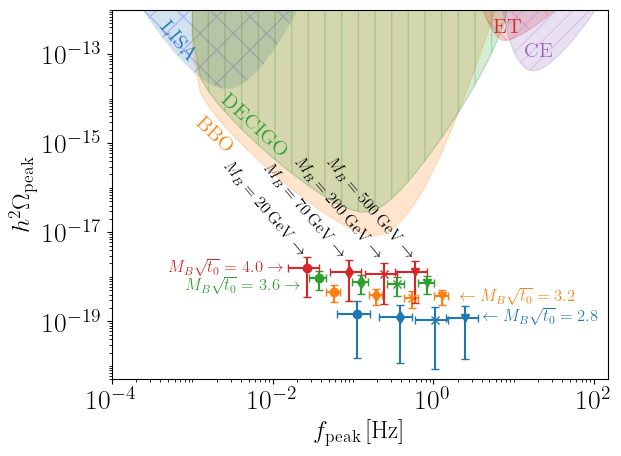

In [18]:
plt.clf()

fig = plt.figure()
ax = plt.axes()

# d=np.zeros(len(dat))+1.0


ax.fill_between( 10**LISA[::500].T[0], 10**LISA[::500].T[1], 1.0, label="LISA", 
                hatch="X", 
                color='C0',
                edgecolor="b", linewidth=0.0, alpha=0.2 )


ax.fill_between( 10**BBO[::400].T[0], 10**BBO[::400].T[1], 1.0, label="BBO", alpha=0.2, color='C1' )
ax.fill_between( 10**DECIGO[::400].T[0], 10**DECIGO[::400].T[1], 1.0, label="DECIGO",
                hatch="|", 
                color='C2',
                edgecolor="g", alpha=0.2 )

ax.fill_between( 10**ET[0:160:2].T[0], 10**ET[0:160:2].T[1], 1.0, label="ET", 
                alpha=0.2,
                hatch='\\', 
                color='C3',
                edgecolor='C3' )
ax.fill_between( 10**CE[:400:5].T[0], 10**CE[:400:5].T[1], 1.0, label="CE", 
                hatch="//", 
                color='C4',
                edgecolor='C4',
                alpha=0.2 )

nn=4
nn2=4

for i in range(nn2):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            ax.errorbar( x=tmp2[3], y=tmp2[4], 
                            xerr=tmp2[5], yerr=tmp2[6],
                           ls='none', capsize=3,
                           marker=markers[i],
                            c=colors[im],
                           # label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$"
                           ) # , label="$M_B="+str(num)+"$GeV"
        else:
            ax.errorbar( x=tmp2[3], y=tmp2[4], 
            xerr=tmp2[5], yerr=tmp2[6],
           ls='none', capsize=3,
           marker=markers[i],
            c=colors[im], ) # , label="$M_B="+str(num)+"$GeV"

plt.xscale("log")
plt.yscale("log")

plt.ylim(5*10**-21, 10**-12)
plt.xlim(10**-4, 150)

# plt.legend()

plt.xticks(fontsize=20)
x_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1, 10), numticks = 10)
ax.xaxis.set_minor_locator(x_minor)
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
y_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1, 10), numticks = 10)
ax.yaxis.set_minor_locator(y_minor)
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plt.yticks(fontsize=20)
ax.set_xlabel("$f_{\\rm peak}{\\rm \\, [Hz]}$", fontsize=18)
ax.set_ylabel("$h^2\\Omega_{\\rm peak}$", fontsize=18)

ax.text(0.0005, 1.3e-18, "$M_B\\sqrt{t_0}=4.0 \\rightarrow$", fontsize=12, color=colors[3])
ax.text(0.0008, 5.1e-19, "$M_B\\sqrt{t_0}=3.6 \\rightarrow$", fontsize=12, color=colors[2])
ax.text(2.1, 2.8e-19, "$\\leftarrow M_B\\sqrt{t_0}=3.2$", fontsize=12, color=colors[1])
ax.text(4., 1.0e-19, "$\\leftarrow M_B\\sqrt{t_0}=2.8 $", fontsize=12, color=colors[0])

ax.text(0.0022, 2.8e-18, "$M_B=20 \\,{\\rm GeV} \\rightarrow$", fontsize=12, rotation=-50)
ax.text(0.007, 2.5e-18, "$M_B=70 \\,{\\rm GeV} \\rightarrow$", fontsize=12, rotation=-50)
ax.text(0.017, 2.5e-18, "$M_B=200 \\,{\\rm GeV} \\rightarrow$", fontsize=12, rotation=-50)
ax.text(0.042, 2.5e-18, "$M_B=500 \\,{\\rm GeV} \\rightarrow$", fontsize=12, rotation=-50)

ax.text(0.00035, 7.0e-14, "${\\rm LISA}$", fontsize=15, rotation=-50, color='C0')
# ax.text(0.00035, 7.0e-14, "LISA", font=, fontsize=15, rotation=-50, color='C0')
ax.text(0.001, 6.0e-16, "${\\rm BBO}$", fontsize=15, rotation=-43, color='C1')
ax.text(0.002, 5.0e-16, "${\\rm DECIGO}$", fontsize=15, rotation=-43, color='C2')
ax.text(5.5, 3.0e-13, "${\\rm ET}$", fontsize=15, rotation=0, color='C3')
ax.text(14.0, 9.0e-14, "${\\rm CE}$", fontsize=15, rotation=0, color='C4')

plt.savefig("sensitivity.pdf", format='pdf',
            bbox_inches='tight'
           )
plt.show()

In [12]:
# plt.clf()

# fig = plt.figure()
# ax = plt.axes()

# # d=np.zeros(len(dat))+1.0


# ax.fill_between( 10**LISA.T[0], 10**LISA.T[1], 1.0, label="LISA", 
#                 hatch="X", 
#                 color='C0',
#                 edgecolor="b", linewidth=0.0, alpha=0.2 )
# ax.fill_between( 10**BBO.T[0], 10**BBO.T[1], 1.0, label="BBO", alpha=0.2, color='C1' )
# ax.fill_between( 10**DECIGO.T[0], 10**DECIGO.T[1], 1.0, label="DECIGO",
#                 hatch="|", 
#                 color='C2',
#                 edgecolor="g", alpha=0.2 )


# ax.fill_between( 10**ET.T[0], 10**ET.T[1], 1.0, label="ET", 
#                 alpha=0.2,
#                 hatch='\\', 
#                 color='C3',
#                 edgecolor='C3' )
# ax.fill_between( 10**CE.T[0], 10**CE.T[1], 1.0, label="CE", 
#                 hatch="//", 
#                 color='C4',
#                 edgecolor='C4',
#                 alpha=0.2 )


# # ax.fill_between( 10**ET.T[0], 10**ET.T[1], 1.0, label="ET", 
# #                 alpha=0.2,
# #                 hatch='/', 
# #                 edgecolor='C3' )
# # ax.fill_between( 10**CE.T[0], 10**CE.T[1], 1.0, label="CE", 
# #                 hatch="\\", 
# #                 edgecolor='C4',
# #                 alpha=0.99 )
# # ax.fill_between( 10**HLVO2.T[0], 10**HLVO2.T[1], 1.0, label="HLVO2", alpha=0.99 )

# #######################################

# nn=4
# nn2=4

# # results=results[::-1]
# for i in range(nn2):
#     tmp = results[i*nn:(i+1)*nn]
#     for im in range(len(tmp)):
#         tmp2 = tmp[im]
#         if i==im:
#             ax.errorbar( x=tmp2[3], y=tmp2[4], 
#                             xerr=tmp2[5], yerr=tmp2[6],
#                            ls='none', capsize=3,
#                            marker=markers[im],
#                             c=colors[i],
#                            # label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$"
#                            ) # , label="$M_B="+str(num)+"$GeV"
#         else:
#             ax.errorbar( x=tmp2[3], y=tmp2[4], 
#             xerr=tmp2[5], yerr=tmp2[6],
#            ls='none', capsize=3,
#            marker=markers[im],
#             c=colors[i],
#            ) # , label="$M_B="+str(num)+"$GeV"

#     # ax.errorbar( x=results[i*nn:(i+1)*nn].T[3], y=results[i*nn:(i+1)*nn].T[4], 
#     #             xerr=results[i*nn:(i+1)*nn].T[5], yerr=results[i*nn:(i+1)*nn].T[6],
#     #            ls='none', capsize=3,
#     #            marker=markers[i],
#     #            label="MB="+str(int(results[i*nn][0]))+"[GeV]") # , label="$M_B="+str(num)+"$GeV"

# # for i, txt in enumerate(n):
# #     txt2 = '{:.2f}'.format(txt)
# #     ax.annotate(txt2, (x[i], y[i]))



# plt.xscale("log")
# plt.yscale("log")

# plt.ylim(5*10**-21, 10**-12)
# plt.xlim(10**-4, 100)



# # legend=plt.legend(loc='center right', markerscale=0.4, fontsize=12, )
# # legend.legend_handles[0].set_height(10.0)
# # legend.legend_handles[1].set_height(10.0)
# # legend.legend_handles[2].set_height(10.0)
# # legend.legend_handles[3].set_height(10.0)
# # legend.legend_handles[4].set_height(10.0)
# # legend.legend_handles[4].markerscale(1.0)

# # plt.title("power-law-integrated sensitivity; annotation is $T_*$ in GeV")

# plt.xticks(fontsize=20)
# # ax.xaxis.set_minor_locator(ticker.LogLocator(subs=np.arange(1, 10) * 0.1, base=10))
# # ax.grid(which="minor", color="0.9", linestyle='--', linewidth=0.5)
# # ax.tick_params(which='minor', length=4) # Make minor ticks visible
# # ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))
# # x_major = matplotlib.ticker.LogLocator(base = 10.0, numticks = 5)
# # ax.xaxis.set_major_locator(y_major)
# x_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1, 10), numticks = 10)
# ax.xaxis.set_minor_locator(x_minor)
# ax.xaxis.set_minor_formatter(ticker.NullFormatter())
# y_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1, 10), numticks = 10)
# ax.yaxis.set_minor_locator(y_minor)
# ax.yaxis.set_minor_formatter(ticker.NullFormatter())


# plt.yticks(fontsize=20)
# ax.set_xlabel("$f_{\\rm peak}{\\rm \\, [Hz]}$", fontsize=20)
# ax.set_ylabel("$h^2\\Omega_{\\rm peak}$", fontsize=20)


# ax.text(0.0006, 1.4e-18, "$M_B\\sqrt{t_0}=4.0 \\rightarrow$", fontsize=11)
# ax.text(0.001, 5.1e-19, "$M_B\\sqrt{t_0}=3.6 \\rightarrow$", fontsize=11)
# ax.text(2.1, 2.8e-19, "$\\leftarrow M_B\\sqrt{t_0}=3.2$", fontsize=11)
# ax.text(4.1, 1.0e-19, "$\\leftarrow M_B\\sqrt{t_0}=2.8 $", fontsize=11)

# ax.text(0.003, 3.e-18, "$M_B=20 \\,{\\rm GeV} \\rightarrow$", fontsize=11, rotation=-50)
# ax.text(0.008, 3.e-18, "$M_B=70 \\,{\\rm GeV} \\rightarrow$", fontsize=11, rotation=-50)
# ax.text(0.019, 3.e-18, "$M_B=200 \\,{\\rm GeV} \\rightarrow$", fontsize=11, rotation=-50)
# ax.text(0.05, 3.e-18, "$M_B=500 \\,{\\rm GeV} \\rightarrow$", fontsize=11, rotation=-50)

# plt.savefig("sensitivity.pdf", format='pdf',
#             bbox_inches='tight'
#            )
# plt.show()

In [13]:
np.arange(1.0, 10.0) * 0.0001

array([0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008,
       0.0009])

In [14]:
np.arange(1.0, 100.0)

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.,
       40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52.,
       53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64., 65.,
       66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77., 78.,
       79., 80., 81., 82., 83., 84., 85., 86., 87., 88., 89., 90., 91.,
       92., 93., 94., 95., 96., 97., 98., 99.])

In [15]:
# fig = plt.figure()
# ax = plt.axes()

# for i in range(nn):
#     tmp = results[i*nn:(i+1)*nn]
#     for im in range(len(tmp)):
#         tmp2 = tmp[im]
#         # print(tmp2)
#         if i==im:
#             plt.errorbar( tmp2[1]*1.005**(+i-2.5), tmp2[13], tmp2[15],
#                          ls='none',
#                          capsize=3,
#                     marker=markers[im],
#                             c=colors[i],
#                         label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$")
#         else:
#             plt.errorbar( tmp2[1]*1.005**(+i-2.5), tmp2[13], tmp2[15],
#                          ls='none',
#                          capsize=3,
#                     marker=markers[im],
#                             c=colors[i],)
#            #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
#            #  xerr=tmp2[5], yerr=tmp2[6],
#            # ls='none', capsize=3,
#            # marker=markers[im],
#            #  c=colors[i],
#            # )
# plt.legend()
# plt.xscale("log")
# plt.yscale("log")

# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# plt.ylabel("$T_c$", fontsize=12)
# plt.xlabel("$M_B$ [GeV]", fontsize=12)

# # plt.savefig("Tc_MB.pdf", bbox_inches='tight')

In [23]:
MB_Tc = np.loadtxt("MB_Tc.dat")

In [26]:
MB_Tc

array([[2.60000000e+00, 1.68097041e+01, 1.69235164e-02],
       [2.61000000e+00, 1.68620342e+01, 1.68212310e-02],
       [2.62000000e+00, 1.69142880e+01, 1.67187466e-02],
       [2.63000000e+00, 1.69664655e+01, 1.66160873e-02],
       [2.64000000e+00, 1.70185670e+01, 1.65132775e-02],
       [2.65000000e+00, 1.70705927e+01, 1.64103425e-02],
       [2.66000000e+00, 1.71225426e+01, 1.63073080e-02],
       [2.67000000e+00, 1.71744170e+01, 1.62042004e-02],
       [2.68000000e+00, 1.72262160e+01, 1.61010468e-02],
       [2.69000000e+00, 1.72779398e+01, 1.59978749e-02],
       [2.70000000e+00, 1.73295886e+01, 1.58947130e-02],
       [2.71000000e+00, 1.73811624e+01, 1.57915905e-02],
       [2.72000000e+00, 1.74326616e+01, 1.56885371e-02],
       [2.73000000e+00, 1.74840862e+01, 1.55855834e-02],
       [2.74000000e+00, 1.75354363e+01, 1.54827610e-02],
       [2.75000000e+00, 1.75867123e+01, 1.53801020e-02],
       [2.76000000e+00, 1.76379142e+01, 1.52776395e-02],
       [2.77000000e+00, 1.76890

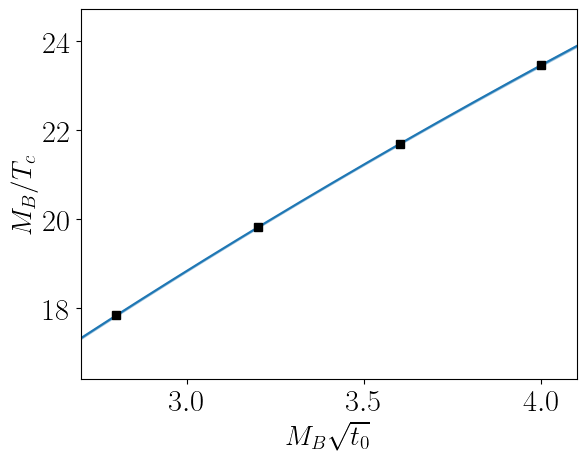

In [27]:
xx=results[:nn].T[1]
yy=results[:nn].T[20]
dyy=results[:nn].T[21]

plt.clf()
plt.errorbar( xx, yy, dyy,
             ls='none',
             capsize=3, marker='s', c="black")

plt.plot( MB_Tc.T[0], MB_Tc.T[1], c='C0' )
plt.fill_between( MB_Tc.T[0], MB_Tc.T[1]+MB_Tc.T[2], MB_Tc.T[1]-MB_Tc.T[2], alpha=0.4, color='C0')

plt.xlim(2.7, 4.1)

plt.ylabel("$M_B/T_c$", fontsize=20)
plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=20)

plt.savefig("MBOverTc_MB.pdf", bbox_inches='tight')
plt.show()

In [30]:
results=np.loadtxt("./results_fin9.dat")

In [31]:
results

array([[2.00000000e+01, 2.80000000e+00, 7.14285714e+00, 1.12918702e-01,
        1.49583460e-19, 4.92514904e-02, 1.34599904e-19, 3.34085670e-01,
        8.66188075e-01, 4.63236339e+05, 4.00188055e-04, 2.01903310e+05,
        1.56845620e-01, 1.56933220e-01, 6.71581696e-05, 6.54023222e-05,
        1.12032585e+00, 1.12095157e+00, 9.59402423e-04, 9.34318888e-04,
        1.78419840e+01, 1.48704457e-02, 8.76000000e-05, 4.29384416e-05],
       [2.00000000e+01, 3.20000000e+00, 6.25000000e+00, 5.75692137e-02,
        4.67634539e-19, 1.15640561e-02, 1.90934553e-19, 3.34824982e-01,
        8.66347514e-01, 2.62533046e+05, 3.57192669e-04, 5.26476333e+04,
        1.61282534e-01, 1.61454534e-01, 5.09720692e-05, 4.74223425e-05,
        1.00801584e+00, 1.00909084e+00, 6.37150865e-04, 5.92779282e-04,
        1.98198212e+01, 1.16426174e-02, 1.72000000e-04, 4.32342272e-05],
       [2.00000000e+01, 3.60000000e+00, 5.55555556e+00, 3.75313683e-02,
        9.21608307e-19, 8.94668699e-03, 4.20231832e-19, 3.3564

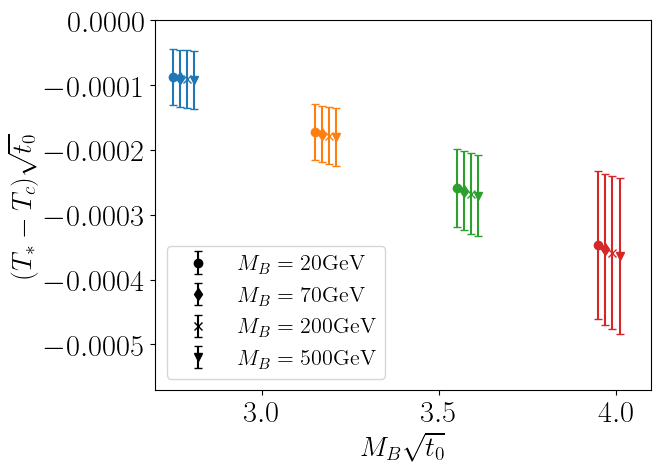

In [32]:
fig = plt.figure()
ax = plt.axes()

# +0.001*(+i-2.5)
for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            plt.errorbar( -1.0, 1.0, 1.0,
                     ls='none',
                    marker=markers[i],
                         capsize=3,
                        c='black',
                        label="$M_B="+str(int(tmp2[0]))+"{\\rm GeV}$")
            plt.errorbar( tmp2[1]+0.02*(+i-2.5), -tmp2[22], tmp2[23],
                         ls='none',
                         capsize=3,
                    marker=markers[i],
                            c=colors[im],
                        # label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$"
                        )
        else:
            plt.errorbar( tmp2[1]+0.02*(+i-2.5), -tmp2[22], tmp2[23],
                         ls='none',
                         capsize=3,
                    marker=markers[i],
                            c=colors[im],)

        #     marker=markers[i],
        #                     c=colors[im],
        #                 # label="$T_c="+'{:.3f}'.format(tmp2[13])+"{\\rm [GeV]}$"
        #                 )
        # else:
        #     plt.errorbar( tmp2[1]+0.02*(+i-2.5), tmp2[7], tmp2[10],
        #                  ls='none',
        #                  capsize=3,
        #             marker=markers[i],
        #                     c=colors[im],)
plt.legend(loc='lower left', fontsize=16)
# plt.xscale("log")
# plt.yscale("log")

plt.xlim(2.7, 4.1)
plt.ylim(-5.7*10.0**-4, 0.0)

# plt.xticks(fontsize=20)
# plt.yticks(fontsize=20)

plt.ylabel("$(T_*-T_c) \\sqrt{t_0}$", fontsize=20)
plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=20)

plt.savefig("TcmTstar_MB.pdf", bbox_inches='tight')

In [33]:
# TmTc1 = np.loadtxt("tmtc1.dat")
# TmTc2 = np.loadtxt("tmtc2.dat")
# TmTc3 = np.loadtxt("tmtc3.dat")
# TmTc4 = np.loadtxt("tmtc4.dat")

In [34]:
results.T[17]

array([ 1.12095157,  1.00909084,  0.92208805,  0.85248581,  3.92333049,
        3.53181793,  3.22730816,  2.98370035, 11.20951568, 10.09090837,
        9.22088046,  8.52485813, 28.02378921, 25.22727092, 23.05220115,
       21.31214533])

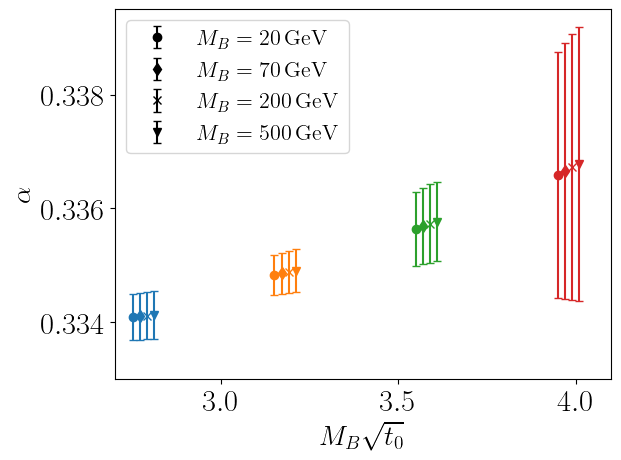

In [37]:
fig = plt.figure()
ax = plt.axes()

for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            plt.errorbar( -1.0, 1.0, 1.0,
                     ls='none',
                    marker=markers[i],
                         capsize=3,
                        c='black',
                        label="$M_B="+str(int(tmp2[0]))+"{\\rm \\,GeV}$")

            plt.errorbar( tmp2[1]+0.02*(+i-2.5), tmp2[7], tmp2[10],
                         ls='none',
                         capsize=3,
                    marker=markers[i],
                            c=colors[im],
                        # label="$T_c="+'{:.3f}'.format(tmp2[13])+"{\\rm [GeV]}$"
                        )
        else:
            plt.errorbar( tmp2[1]+0.02*(+i-2.5), tmp2[7], tmp2[10],
                         ls='none',
                         capsize=3,
                    marker=markers[i],
                            c=colors[im],)
           #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
           #  xerr=tmp2[5], yerr=tmp2[6],
           # ls='none', capsize=3,
           # marker=markers[im],
           #  c=colors[i],
           # )

# i=1
# tmp = results[i*nn:(i+1)*nn]
# plt.plot( tmp.T[1], tmp.T[7],
#           ls='dashed',
#             c='gray', 
#                         # label="$T_c="+'{:.3f}'.format(tmp2[13])+"{\\rm [GeV]}$"
#                         )
plt.legend( fontsize=16 )
# plt.xscale("log")
# plt.yscale("log")

plt.xlim(2.7, 4.1)
plt.ylim(0.333, 0.3395)

plt.xticks()
plt.yticks()

plt.ylabel("$\\alpha$", fontsize=20)
plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=20)

plt.savefig("alpha_MB.pdf", bbox_inches='tight')

In [38]:
# fig = plt.figure()
# ax = plt.axes()

# for i in range(nn):
#     tmp = results[i*nn:(i+1)*nn]
#     for im in range(len(tmp)):
#         tmp2 = tmp[im]
#         if i==im:
#             plt.errorbar( -1.0, 1.0, 1.0,
#                      ls='none',
#                     marker='none',
#                          capsize=3,
#                         c=colors[i],
#                         label="$M_B="+str(int(tmp2[0]))+"{\\rm \\,GeV}$")

#             plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[7], tmp2[10],
#                          ls='none',
#                          capsize=3,
#                     marker=markers[im],
#                             c=colors[i],
#                         # label="$T_c="+'{:.3f}'.format(tmp2[13])+"{\\rm [GeV]}$"
#                         )
#         else:
#             plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[7], tmp2[10],
#                          ls='none',
#                          capsize=3,
#                     marker=markers[im],
#                             c=colors[i],)
#            #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
#            #  xerr=tmp2[5], yerr=tmp2[6],
#            # ls='none', capsize=3,
#            # marker=markers[im],
#            #  c=colors[i],
#            # )

# # i=1
# # tmp = results[i*nn:(i+1)*nn]
# # plt.plot( tmp.T[1], tmp.T[7],
# #           ls='dashed',
# #             c='gray', 
# #                         # label="$T_c="+'{:.3f}'.format(tmp2[13])+"{\\rm [GeV]}$"
# #                         )
# plt.legend( fontsize=16 )
# # plt.xscale("log")
# # plt.yscale("log")

# plt.xlim(2.7, 4.1)
# plt.ylim(0.333, 0.339)

# plt.xticks()
# plt.yticks()

# plt.ylabel("$\\alpha$", fontsize=20)
# plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=20)

# plt.savefig("alpha_MB.pdf", bbox_inches='tight')

In [39]:
results[i*nn:(i+1)*nn].T[1]

array([2.8, 3.2, 3.6, 4. ])

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tick

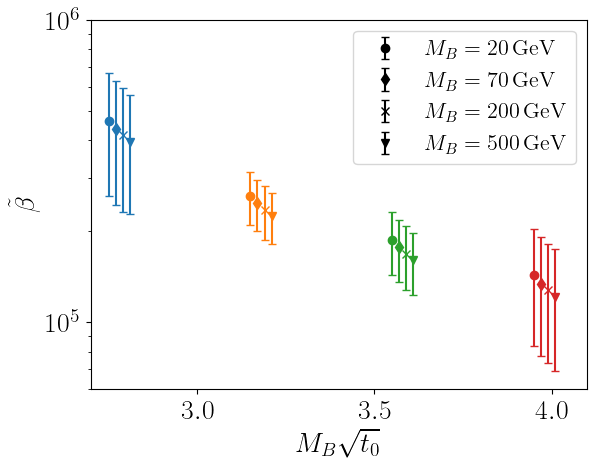

In [42]:
fig = plt.figure()
ax = plt.axes()

for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            plt.errorbar( -1.0, 1.0, 1.0,
                     ls='none',
                    marker=markers[i],
                         capsize=3,
                        c='black',
                        label="$M_B="+str(int(tmp2[0]))+"{\\rm \\,GeV}$")

            plt.errorbar( tmp2[1]+0.02*(+i-2.5), tmp2[9], tmp2[11],
                         ls='none',
                         capsize=3,
                    marker=markers[i],
                            c=colors[im],
                        # label="$T_c="+'{:.3f}'.format(tmp2[13])+"{\\rm [GeV]}$"
                        )
        else:
            plt.errorbar( tmp2[1]+0.02*(+i-2.5), tmp2[9], tmp2[11],
                         ls='none',
                         capsize=3,
                    marker=markers[i],
                            c=colors[im],)
           #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
           #  xerr=tmp2[5], yerr=tmp2[6],
           # ls='none', capsize=3,
           # marker=markers[im],
           #  c=colors[i],
           # )


# i=2
# tmp = results[i*nn:(i+1)*nn]
# plt.plot( tmp.T[1], tmp.T[9],
#           ls='dashed',
#             c='gray', 
#                         # label="$T_c="+'{:.3f}'.format(tmp2[13])+"{\\rm [GeV]}$"
#                         )
# plt.legend( fontsize=16 )


plt.legend(fontsize=16)
# plt.xscale("log")
plt.yscale("log")

plt.xlim(2.7, 4.1)
plt.ylim(6*10.0**4, 1*10.0**6)

def y_fmt(x, y):
    return '{:2.2e}'.format(x)

# ax.xaxis.set_major_formatter(mticker.LogFormatter(base=10.0, labelOnlyBase=False))
# ax.yaxis.set_major_formatter(tick.LogFormatter(base=10.0, labelOnlyBase=False))
# plt.ysclae
# ax.yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.ylabel("$\\tilde\\beta$", fontsize=20)
plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=20)

plt.savefig("betatilde_MB.pdf", bbox_inches='tight')

In [43]:
# fig = plt.figure()
# ax = plt.axes()

# for i in range(nn):
#     tmp = results[i*nn:(i+1)*nn]
#     for im in range(len(tmp)):
#         tmp2 = tmp[im]
#         if i==im:
#             plt.errorbar( -1.0, 1.0, 1.0,
#                      ls='none',
#                     marker='none',
#                          capsize=3,
#                         c=colors[i],
#                         label="$M_B="+str(int(tmp2[0]))+"{\\rm \\,GeV}$")

#             plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[9], tmp2[11],
#                          ls='none',
#                          capsize=3,
#                     marker=markers[im],
#                             c=colors[i],
#                         # label="$T_c="+'{:.3f}'.format(tmp2[13])+"{\\rm [GeV]}$"
#                         )
#         else:
#             plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[9], tmp2[11],
#                          ls='none',
#                          capsize=3,
#                     marker=markers[im],
#                             c=colors[i],)
#            #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
#            #  xerr=tmp2[5], yerr=tmp2[6],
#            # ls='none', capsize=3,
#            # marker=markers[im],
#            #  c=colors[i],
#            # )


# # i=2
# # tmp = results[i*nn:(i+1)*nn]
# # plt.plot( tmp.T[1], tmp.T[9],
# #           ls='dashed',
# #             c='gray', 
# #                         # label="$T_c="+'{:.3f}'.format(tmp2[13])+"{\\rm [GeV]}$"
# #                         )
# # plt.legend( fontsize=16 )


# plt.legend(fontsize=16)
# # plt.xscale("log")
# plt.yscale("log")

# plt.xlim(2.7, 4.1)
# plt.ylim(6*10.0**4, 1*10.0**6)

# def y_fmt(x, y):
#     return '{:2.2e}'.format(x)

# # ax.xaxis.set_major_formatter(mticker.LogFormatter(base=10.0, labelOnlyBase=False))
# # ax.yaxis.set_major_formatter(tick.LogFormatter(base=10.0, labelOnlyBase=False))
# # plt.ysclae
# # ax.yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

# plt.xticks(fontsize=20)
# plt.yticks(fontsize=20)

# plt.ylabel("$\\tilde\\beta$", fontsize=20)
# plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=20)

# plt.savefig("betatilde_MB.pdf", bbox_inches='tight')

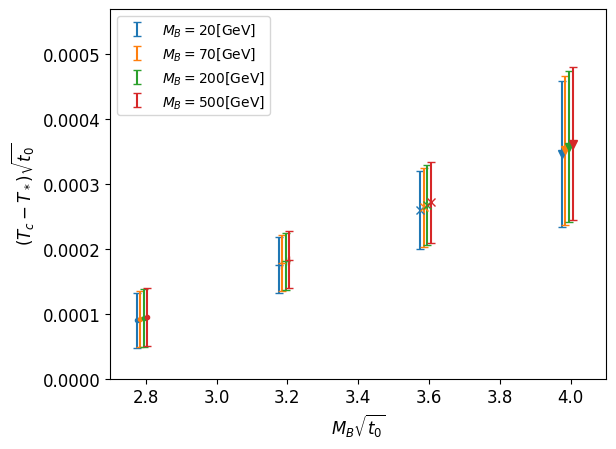

In [29]:
fig = plt.figure()
ax = plt.axes()

# +0.001*(+i-2.5)
for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            plt.errorbar( -1.0, 1.0, 1.0,
                     ls='none',
                    marker='none',
                         capsize=3,
                        c=colors[i],
                        label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}$")
            plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[22], tmp2[23],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],
                        # label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$"
                        )
        else:
            plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[22], tmp2[23],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],)
           #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
           #  xerr=tmp2[5], yerr=tmp2[6],
           # ls='none', capsize=3,
           # marker=markers[im],
           #  c=colors[i],
           # )
plt.legend(loc='upper left')
# plt.xscale("log")
# plt.yscale("log")

plt.xlim(2.7, 4.1)
plt.ylim(0.0, 5.7*10.0**-4)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylabel("$(T_c-T_*) \\sqrt{t_0}$", fontsize=12)
plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=12)

plt.savefig("TcmTstar_MB.pdf", bbox_inches='tight')

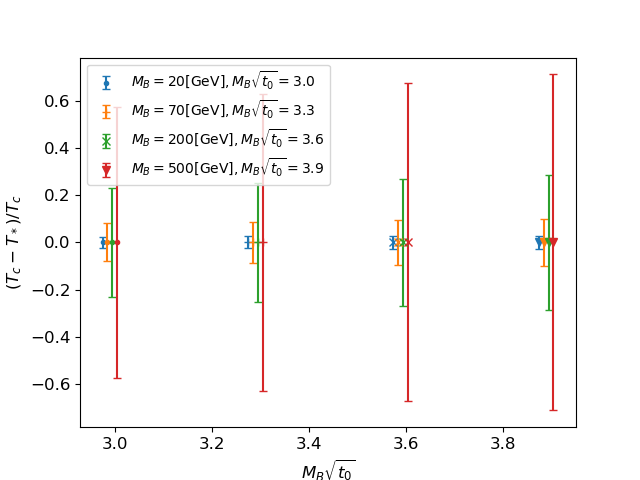

In [33]:
# fig = plt.figure()
# ax = plt.axes()

# # +0.001*(+i-2.5)
# for i in range(nn):
#     tmp = results[i*nn:(i+1)*nn]
#     for im in range(len(tmp)):
#         tmp2 = tmp[im]
#         if i==im:
#             plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[15]-tmp2[14], tmp2[18],
#                          ls='none',
#                          capsize=3,
#                     marker=markers[im],
#                             c=colors[i],
#                         label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$")
#         else:
#             plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[15]-tmp2[14], tmp2[18],
#                          ls='none',
#                          capsize=3,
#                     marker=markers[im],
#                             c=colors[i],)
#            #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
#            #  xerr=tmp2[5], yerr=tmp2[6],
#            # ls='none', capsize=3,
#            # marker=markers[im],
#            #  c=colors[i],
#            # )
# plt.legend()
# # plt.xscale("log")
# # plt.yscale("log")

# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# plt.ylabel("$(T_c-T_*)/T_c$", fontsize=12)
# plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=12)

# plt.savefig("TcmTstar_MB.pdf", bbox_inches='tight')

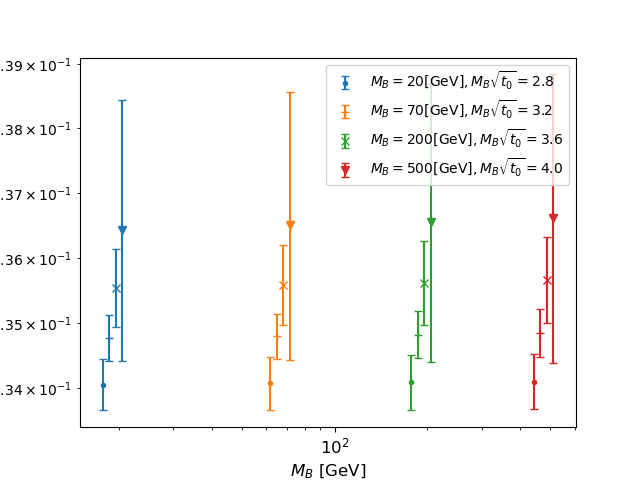

In [10]:
fig = plt.figure()
ax = plt.axes()

for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            plt.errorbar( tmp2[0]*1.05**(+im-2.5), tmp2[7], tmp2[10],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],
                        label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$")
        else:
            plt.errorbar( tmp2[0]*1.05**(+im-2.5), tmp2[7], tmp2[10],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],)
           #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
           #  xerr=tmp2[5], yerr=tmp2[6],
           # ls='none', capsize=3,
           # marker=markers[im],
           #  c=colors[i],
           # )
plt.legend()
plt.xscale("log")
plt.yscale("log")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylabel("$\\alpha$", fontsize=12)
plt.xlabel("$M_B$ [GeV]", fontsize=12)

plt.savefig("alpha_MB.pdf", bbox_inches='tight')

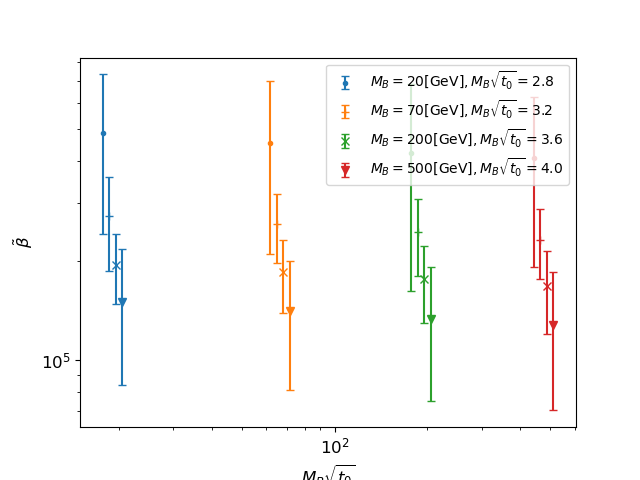

In [11]:
fig = plt.figure()
ax = plt.axes()

for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            plt.errorbar( tmp2[0]*1.05**(+im-2.5), tmp2[9], tmp2[11],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],
                        label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$")
        else:
            plt.errorbar( tmp2[0]*1.05**(+im-2.5), tmp2[9], tmp2[11],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],)
           #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
           #  xerr=tmp2[5], yerr=tmp2[6],
           # ls='none', capsize=3,
           # marker=markers[im],
           #  c=colors[i],
           # )
plt.legend()
plt.xscale("log")
plt.yscale("log")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylabel("$\\tilde\\beta$", fontsize=12)
plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=12)

plt.savefig("beta_MB.pdf", bbox_inches='tight')

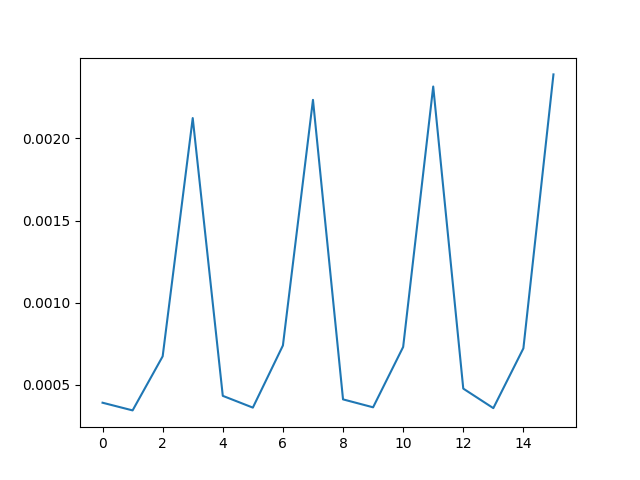

In [16]:
plt.clf()
plt.plot( results.T[10] )
results.T[11]
plt.show()

In [141]:
results.T[11]

array([0.16443425, 0.17110715, 0.17778004, 0.18445293, 0.16443425,
       0.17110715, 0.17778004, 0.18445293, 0.16443425, 0.17110715,
       0.17778004, 0.18445293, 0.16443425, 0.17110715, 0.17778004,
       0.18445293])

In [10]:
results[6*i::6]

NameError: name 'i' is not defined

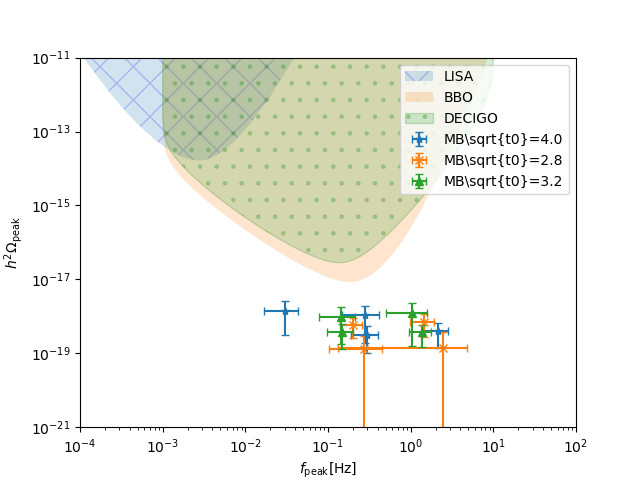

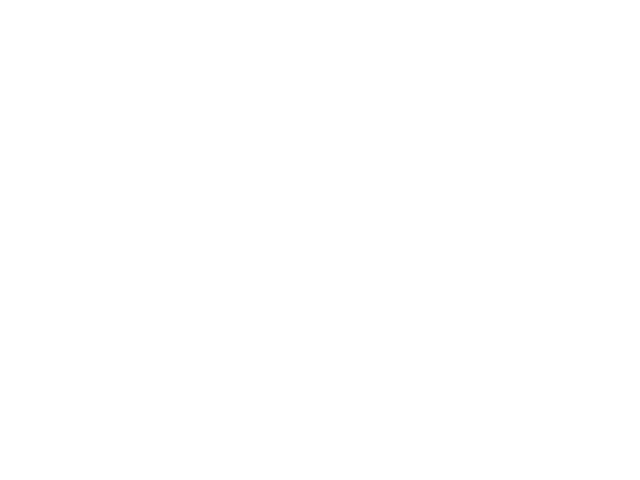

In [11]:
plt.clf()

fig = plt.figure()
ax = plt.axes()

# d=np.zeros(len(dat))+1.0

ax.fill_between( 10**LISA.T[0], 10**LISA.T[1], 1.0, label="LISA", 
                hatch="X", 
                edgecolor="b", linewidth=0.0, alpha=0.2 )
ax.fill_between( 10**BBO.T[0], 10**BBO.T[1], 1.0, label="BBO", alpha=0.2 )
ax.fill_between( 10**DECIGO.T[0], 10**DECIGO.T[1], 1.0, label="DECIGO",
                hatch=".", 
                edgecolor="g", alpha=0.2 )
# ax.fill_between( 10**HLVO2.T[0], 10**HLVO2.T[1], 1.0, label="HLVO2", alpha=0.2 )

#######################################5

i=3
ax.errorbar( x=results[i::6].T[3], y=results[i::6].T[4], 
            xerr=results[i::6].T[5], yerr=results[i::6].T[6],
           ls='none', capsize=3,
           marker=markers[i],
           label="MB\sqrt{t0}="+str(results[i][1])) # , label="$M_B="+str(num)+"$GeV"
i=4
ax.errorbar( x=results[i::6].T[3], y=results[i::6].T[4], 
            xerr=results[i::6].T[5], yerr=results[i::6].T[6],
           ls='none', capsize=3,
           marker=markers[i],
           label="MB\sqrt{t0}="+str(results[i][1])) # , label="$M_B="+str(num)+"$GeV"
i=5
ax.errorbar( x=results[i::6].T[3], y=results[i::6].T[4], 
            xerr=results[i::6].T[5], yerr=results[i::6].T[6],
           ls='none', capsize=3,
           marker=markers[i],
           label="MB\sqrt{t0}="+str(results[i][1])) # , label="$M_B="+str(num)+"$GeV"
# for i, txt in enumerate(n):
#     txt2 = '{:.2f}'.format(txt)
#     ax.annotate(txt2, (x[i], y[i]))



plt.xscale("log")
plt.yscale("log")

plt.ylim(10**-21, 10**-11)
plt.xlim(10**-4, 100)


plt.legend()

# plt.title("power-law-integrated sensitivity; annotation is $T_*$ in GeV")

plt.xlabel("$f_{\\rm peak}$[Hz]")
plt.ylabel("$h^2\\Omega_{\\rm peak}$")

plt.show()